In [109]:
# Brazilian E-Commerce Data Analysis

#This project analyzes customer behavior, delivery performance, and sales trends using the Olist dataset.

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [111]:
import os
os.getcwd()

'C:\\Users\\TEST'

In [112]:

# Update this path according to your system
path = r"C:\excel data file\DATASETS"

customers = pd.read_csv(path + r"\olist_customers_dataset.csv")
orders = pd.read_csv(path + r"\olist_orders_dataset.csv")
order_items = pd.read_csv(path + r"\olist_order_items_dataset.csv")
payments = pd.read_csv(path + r"\olist_order_payments_dataset.csv")
reviews = pd.read_csv(path + r"\olist_order_reviews_dataset.csv")
products = pd.read_csv(path + r"\olist_products_dataset.csv")
sellers = pd.read_csv(path + r"\olist_sellers_dataset.csv")
category_translation = pd.read_csv(path + r"\product_category_name_translation.csv")
print("All files loaded successfully!")

All files loaded successfully!


In [113]:
#View First Few Rows

In [114]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [115]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [116]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [117]:
# Understand Dataset Structure

In [118]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [119]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [120]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [121]:
#Check Missing Values

In [122]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [123]:
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [124]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [125]:
orders['order_purchase_timestamp'] = pd.to_datetime( orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime( orders['order_delivered_customer_date'])
                                                     

In [126]:
#Merge Datasets

In [127]:
df = pd.merge(orders,customers, on ="customer_id", how = "left")

In [128]:
df = pd.merge ( df , order_items, on ="order_id",how = "left")

In [129]:
df = pd.merge(df,payments , on ="order_id", how = "left")

In [130]:
#Create New Useful Columns

In [131]:
df['delivery_time'] = ( 
    df['order_delivered_customer_date' ] 
    - df['order_purchase_timestamp']).dt.days

In [132]:
# Basic Data Analysis

In [133]:
#Analysis 1 — Total Orders
#Counts unique orders
df ['order_id'].nunique() 

99441

In [134]:
#Analysis 2 — Total Revenue
df ['payment_value'].sum()

np.float64(20470726.659999996)

In [135]:
#Analysis 3 — Orders by State
orders_by_state = df['customer_state'].value_counts()
orders_by_state.head()

customer_state
SP    49967
RJ    15420
MG    13738
RS     6521
PR     6017
Name: count, dtype: int64

In [136]:
#Analysis 4 — Most Used Payment Method
df['payment_type'].value_counts()

payment_type
credit_card    87286
boleto         23037
voucher         6407
debit_card      1698
not_defined        3
Name: count, dtype: int64

In [137]:
#Analysis 5 — Average Delivery Time
df['delivery_time'].mean()

np.float64(12.019237288872276)

In [138]:
# Monthly Sales Analysis

In [139]:
#Create Month Column
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

In [140]:
#Group by Month
monthly_sales = df.groupby('month')['payment_value'].sum()
monthly_sales

month
2016-09        388.47
2016-10      76120.17
2016-12         19.62
2017-01     189015.66
2017-02     349701.93
2017-03     544738.23
2017-04     510891.55
2017-05     731017.09
2017-06     608891.38
2017-07     744599.53
2017-08     876129.37
2017-09    1023095.49
2017-10    1031505.53
2017-11    1599444.18
2017-12    1057582.34
2018-01    1415348.54
2018-02    1311260.71
2018-03    1480045.50
2018-04    1497843.94
2018-05    1511113.00
2018-06    1298685.81
2018-07    1359421.48
2018-08    1248837.93
2018-09       4439.54
2018-10        589.67
Freq: M, Name: payment_value, dtype: float64

In [141]:
#Visualization:Graphs

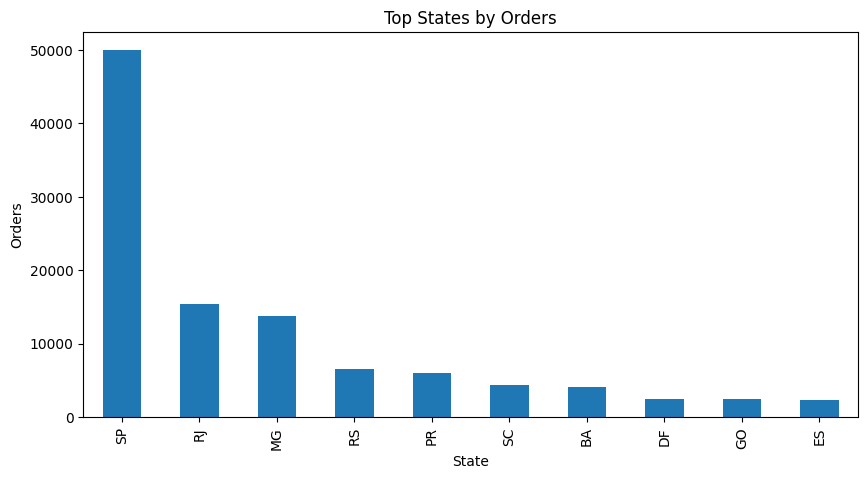

In [142]:
#Graph 1 — Orders by State
plt.figure(figsize=(10,5))
orders_by_state.head(10).plot( kind ='bar')
plt.title("Top States by Orders")
plt.xlabel("State")
plt.ylabel("Orders")

plt.show()

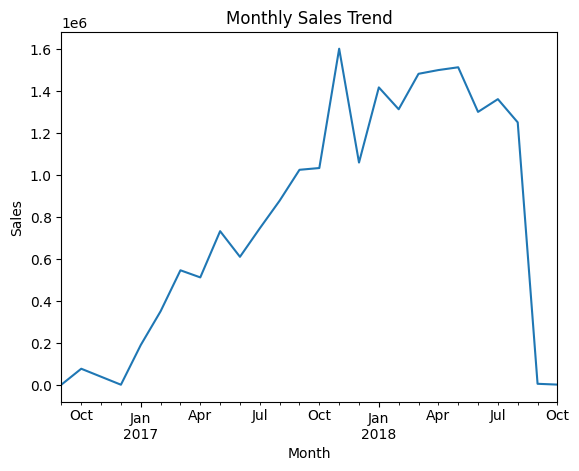

In [143]:
#Graph 2 — Monthly Sales Trend
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

In [144]:
#Product Category Analysis

In [145]:
#Merge category names:
products = pd.merge(
    products,
    category_translation,
    on="product_category_name",
    how="left"
)

In [146]:
df = pd.merge(df,products, on ="product_id",how = "left")

In [147]:
#Top Selling Categories
top_categories = df['product_category_name_english'].value_counts()
top_categories.head(10)


product_category_name_english
bed_bath_table           11823
health_beauty             9975
sports_leisure            8945
furniture_decor           8744
computers_accessories     8082
housewares                7355
watches_gifts             6201
telephony                 4721
garden_tools              4574
auto                      4379
Name: count, dtype: int64

In [148]:
#Customer Review Analysis

In [149]:
#Average Rating
reviews['review_score'].mean()

np.float64(4.08642062404257)

In [150]:
#Merge Reviews
df = pd.merge( df,reviews,on ="order_id" , how="left")


In [151]:
# Reviews vs Delivery Time Analyze
result = df.groupby('review_score')['delivery_time'].mean().reset_index()
result


,review_score,delivery_time
0,1.0,19.099992
1,2.0,15.381893
2,3.0,13.552435
3,4.0,11.778330
4,5.0,10.203253


In [152]:
#Advanced Analysis
#1. Revenue by State
state_revenue = df.groupby(
    'customer_state'
)['payment_value'].sum().sort_values(ascending=False).reset_index()

state_revenue.head(10)

,customer_state,payment_value
0,SP,7726078.35
1,RJ,2795615.67
2,MG,2351221.09
3,RS,1160175.66
4,PR,1079795.49
5,BA,805070.98
6,SC,801276.45
7,GO,520481.65
8,DF,438095.32
9,ES,408611.64


In [153]:
#2. Delivery Delay Analysis
# coverted both colun to datetime
df['order_delivered_customer_date'] = pd.to_datetime(
    df['order_delivered_customer_date']
)

df['order_estimated_delivery_date'] = pd.to_datetime(
    df['order_estimated_delivery_date']
)

In [154]:
#Create Delay Column

df['delivery_delay'] = (
    df['order_delivered_customer_date']
    - df['order_estimated_delivery_date']
).dt.days
#Analyze Delay
df['delivery_delay'].mean()

np.float64(-12.04839183560602)

In [155]:
#Delay vs Review
df.groupby('review_score')['delivery_delay'].mean().reset_index()

,review_score,delivery_delay
0,1.0,-5.993827
1,2.0,-9.748141
2,3.0,-11.114301
3,4.0,-12.468533
4,5.0,-13.443437


In [156]:
#3. Seller Performance
seller_perf = df.groupby('seller_id').agg({'payment_value': 'sum','order_id': 'count'
}).sort_values(by='payment_value', ascending=False)

seller_perf.head()

,payment_value,order_id
seller_id,,
7c67e1448b00f6e969d365cea6b010ab,512645.19,1463
1025f0e2d44d7041d6cf58b6550e0bfa,312456.49,1477
4a3ca9315b744ce9f8e9374361493884,306138.80,2155
1f50f920176fa81dab994f9023523100,291918.98,2017
53243585a1d6dc2643021fd1853d8905,284903.08,437


In [157]:
#4. Product Weight vs Freight Cost
df[['product_weight_g', 'freight_value']].corr()
#Finds relationship between: Product weight,Shipping cost
#Insight:If correlation high → heavier products cost more to ship

,product_weight_g,freight_value
product_weight_g,1.000000,0.611587
freight_value,0.611587,1.000000


In [158]:
#5. Customer Repeat Purchases
repeat_customers = df.groupby( 'customer_unique_id')['order_id'].nunique()
repeat_customers = repeat_customers[repeat_customers > 1]
len(repeat_customers)

2997

<Axes: xlabel='month'>

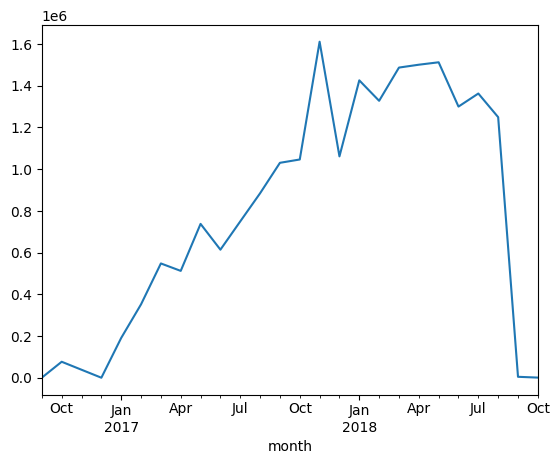

In [159]:
#Bonus — Monthly Revenue Trend
monthly_sales = df.groupby('month')['payment_value'].sum()
monthly_sales.plot()

In [160]:
#Save Final Clean Dataset
df.to_csv("final_olist_dataset.csv",index=False)

In [161]:
import os
os.getcwd()

'C:\\Users\\TEST'